# Model Robustness Benchmark Analysis

This notebook analyzes the full benchmark results across models, tasks, regimes, and distraction types.

It works from the scored JSONL files produced by `evaluate_model.py`, and optionally uses the failure-analysis CSVs if they are available.

Main questions:

1. Which model performs best overall?
2. How much does performance drop from clean to distracted prompts?
3. Which distraction families are most harmful?
4. Which task families are most fragile?
5. How do bounded and unbounded regimes differ?
6. What kinds of failures occur?
7. How much do QA results change under relaxed span-boundary scoring?

## 0. Setup

This notebook can be run either from the repository root or from `evaluation/analysis/`.
The path cell below automatically walks upward until it finds the project root containing `data/prompts/prompt_instances.jsonl` and `evaluation/hpc_results/scored/`.


In [46]:
from pathlib import Path
import json
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 1. Locate result files

For your current repository structure, the scored model outputs live in:

`evaluation/hpc_results/scored/`

and notebook exports should be written to:

`evaluation/analysis_outputs/notebook_exports/`

The next cell detects those paths robustly, regardless of whether Jupyter starts in the repo root or inside `evaluation/analysis/`.


In [47]:
def find_project_root(start: Path) -> Path:
    """Walk upward until we find the repository root.

    The root is identified by the benchmark file and the evaluation folder.
    This makes the notebook robust when opened from VS Code/Jupyter with
    either the repo root or evaluation/analysis as the working directory.
    """
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        benchmark = candidate / "data" / "prompts" / "prompt_instances.jsonl"
        eval_dir = candidate / "evaluation"
        if benchmark.exists() and eval_dir.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the project root. Start this notebook from inside the repo, "
        "or set PROJECT_ROOT manually."
    )

PROJECT_ROOT = find_project_root(Path.cwd())

# Your actual results directory from the repo tree you shared.
SCORED_DIR = PROJECT_ROOT / "evaluation" / "hpc_results" / "scored"
RAW_DIR = PROJECT_ROOT / "evaluation" / "hpc_results" / "raw"
FULL_METRICS_DIR = PROJECT_ROOT / "evaluation" / "hpc_results" / "full"
BENCHMARK_PATH = PROJECT_ROOT / "data" / "prompts" / "prompt_instances.jsonl"
FAILURE_OUTPUT_DIR = PROJECT_ROOT / "evaluation" / "analysis_outputs"
RELAXED_OUTPUT_DIR = FAILURE_OUTPUT_DIR / "relaxed_scoring"


OUTPUT_DIR = PROJECT_ROOT / "evaluation" / "analysis_outputs" / "notebook_exports"
PLOT_DIR = OUTPUT_DIR / "plots"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

required_dirs = [SCORED_DIR, RAW_DIR, FULL_METRICS_DIR]
missing_dirs = [str(p) for p in required_dirs if not p.exists()]
if missing_dirs:
    raise FileNotFoundError("Missing expected result directories: " + ", ".join(missing_dirs))

print("Working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Using scored results dir:", SCORED_DIR)
print("Using raw results dir:", RAW_DIR)
print("Using full metrics dir:", FULL_METRICS_DIR)
print("Benchmark path:", BENCHMARK_PATH)
print("Notebook export dir:", OUTPUT_DIR)


Working directory: c:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis
Detected project root: C:\code\testing\LLMs_Robustness_Under_Distractions
Using scored results dir: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\hpc_results\scored
Using raw results dir: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\hpc_results\raw
Using full metrics dir: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\hpc_results\full
Benchmark path: C:\code\testing\LLMs_Robustness_Under_Distractions\data\prompts\prompt_instances.jsonl
Notebook export dir: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports


In [48]:
MODEL_FILES = {
    "gemma": {
        "display": "Gemma-2-9B-it",
        "family": "Gemma",
        "params_b": 9,
        "is_instruct": True,
        "filename": "full_scored_gemma2_9b_it_jsonforced.jsonl",
    },
    "llama": {
        "display": "Llama-3.1-8B-Instruct",
        "family": "Llama",
        "params_b": 8,
        "is_instruct": True,
        "filename": "full_scored_llama31_8b_instruct_jsonforced.jsonl",
    },
    "mistral_instruct": {
        "display": "Mistral-7B-Instruct-v0.3",
        "family": "Mistral",
        "params_b": 7,
        "is_instruct": True,
        "filename": "full_scored_mistral_7b_instruct_v03_jsonforced.jsonl",
    },
    "mistral_base": {
        "display": "Mistral-7B-v0.3 Base",
        "family": "Mistral",
        "params_b": 7,
        "is_instruct": False,
        "filename": "full_scored_mistral_7b_base_v03_jsonforced.jsonl",
    },
    "qwen7b": {
        "display": "Qwen2.5-7B-Instruct",
        "family": "Qwen",
        "params_b": 7,
        "is_instruct": True,
        "filename": "full_scored_qwen25_7b_instruct_jsonforced.jsonl",
    },
    "qwen14b": {
        "display": "Qwen2.5-14B-Instruct",
        "family": "Qwen",
        "params_b": 14,
        "is_instruct": True,
        "filename": "full_scored_qwen25_14b_instruct_jsonforced.jsonl",
    },
}

EXCLUDED_MODEL_KEYS = {"mistral_base"}

ACTIVE_MODEL_FILES = {
    key: value
    for key, value in MODEL_FILES.items()
    if key not in EXCLUDED_MODEL_KEYS
}

MODEL_ORDER = [
    "gemma",
    "qwen14b",
    "qwen7b",
    "llama",
    "mistral_instruct",
]

# MODEL_ORDER = ["gemma", "qwen14b", "qwen7b", "llama", "mistral_instruct", "mistral_base"]

TASK_ORDER = [
    "single_label_classification",
    "multi_label_classification",
    "information_extraction",
    "rule_based_transformation",
    "extractive_qa",
]
REGIME_ORDER = ["bounded", "unbounded"]
DISTRACTION_ORDER = [
    "clean",
    "irrelevant_prefix",
    "irrelevant_suffix",
    "instruction_in_the_middle",
    "conflicting_instruction",
    "negation_distraction",
    "style_distraction",
    "length_stress",
]

## 2. Load scored JSONL files

In [49]:
def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

all_rows = []
missing = []

for model_key, meta in ACTIVE_MODEL_FILES.items():
    path = SCORED_DIR / meta["filename"]
    if not path.exists():
        missing.append((model_key, path))
        continue
    rows = load_jsonl(path)
    for row in rows:
        row["model"] = model_key
        row["model_display"] = meta["display"]
        row["model_family"] = meta["family"]
        row["params_b"] = meta["params_b"]
        row["is_instruct_model"] = meta["is_instruct"]
    all_rows.extend(rows)

if missing:
    print("Missing result files:")
    for model_key, path in missing:
        print(f"- {model_key}: {path}")

if not all_rows:
    raise FileNotFoundError("No scored JSONL files were loaded. Check SCORED_DIR and MODEL_FILES.")

df = pd.DataFrame(all_rows)

df = df[~df["model"].astype(str).isin(EXCLUDED_MODEL_KEYS)].copy()

# Derived columns.
df["correct"] = df["is_correct"].astype(bool).astype(int)
df["parse_success_bool"] = df["parse_success"].astype(bool)
df["parse_fail"] = (~df["parse_success_bool"]).astype(int)
df["is_clean_bool"] = df["is_clean"].astype(bool)
df["is_distracted"] = (~df["is_clean_bool"]).astype(int)

df["model"] = pd.Categorical(
    df["model"].astype(str),
    categories=MODEL_ORDER,
    ordered=True
)
df["task_name"] = pd.Categorical(df["task_name"], categories=TASK_ORDER, ordered=True)
df["regime"] = pd.Categorical(df["regime"], categories=REGIME_ORDER, ordered=True)
df["distraction_type"] = pd.Categorical(df["distraction_type"], categories=DISTRACTION_ORDER, ordered=True)

print("Loaded rows:", len(df))
display(df.groupby("model", observed=False).size().reset_index(name="n"))

Loaded rows: 20000


,model,n
0,gemma,4000
1,qwen14b,4000
2,qwen7b,4000
3,llama,4000
4,mistral_instruct,4000


## 3. Sanity checks

Expected counts:

- 4000 rows per model
- 800 rows per model × task
- 2000 rows per model × regime
- 500 rows per model × distraction type

In [50]:
display(df.groupby("model", observed=False).size().reset_index(name="n"))
display(df.groupby(["model", "task_name"], observed=False).size().reset_index(name="n").head(40))
display(df.groupby(["model", "regime"], observed=False).size().reset_index(name="n"))
display(df.groupby(["model", "distraction_type"], observed=False).size().reset_index(name="n").head(60))

,model,n
0,gemma,4000
1,qwen14b,4000
2,qwen7b,4000
3,llama,4000
4,mistral_instruct,4000


,model,task_name,n
0,gemma,single_label_classification,800
1,gemma,multi_label_classification,800
2,gemma,information_extraction,800
3,gemma,rule_based_transformation,800
4,gemma,extractive_qa,800
5,qwen14b,single_label_classification,800
6,qwen14b,multi_label_classification,800
7,qwen14b,information_extraction,800
8,qwen14b,rule_based_transformation,800
9,qwen14b,extractive_qa,800


,model,regime,n
0,gemma,bounded,2000
1,gemma,unbounded,2000
2,qwen14b,bounded,2000
3,qwen14b,unbounded,2000
4,qwen7b,bounded,2000
5,qwen7b,unbounded,2000
6,llama,bounded,2000
7,llama,unbounded,2000
8,mistral_instruct,bounded,2000
9,mistral_instruct,unbounded,2000


,model,distraction_type,n
0,gemma,clean,500
1,gemma,irrelevant_prefix,500
2,gemma,irrelevant_suffix,500
3,gemma,instruction_in_the_middle,500
4,gemma,conflicting_instruction,500
5,gemma,negation_distraction,500
6,gemma,style_distraction,500
7,gemma,length_stress,500
8,qwen14b,clean,500
9,qwen14b,irrelevant_prefix,500


## 4. Helper functions

In [51]:
def summarize(group_cols):
    return (
        df.groupby(group_cols, observed=True)
        .agg(
            accuracy=("correct", "mean"),
            parse_failure_rate=("parse_fail", "mean"),
            n=("correct", "count"),
        )
        .reset_index()
    )


def save_table(table, name):
    path = TABLE_DIR / name
    table.to_csv(path, index=False)
    print("Saved", path)
    return path


def save_current_plot(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved", path)


def plot_bar(table, x, y, title, ylabel="Accuracy", rotation=30, filename=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(table[x].astype(str), table[y])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ymax = max(1.0, float(table[y].max()) * 1.15 if len(table) else 1.0)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="x", rotation=rotation)
    for i, v in enumerate(table[y]):
        ax.text(i, v + ymax * 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    if filename:
        save_current_plot(filename)
    plt.show()

def save_plot(fig, filename):
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {path}")

def plot_grouped_bar(table, x, group, y, title, ylabel="Accuracy", filename=None):
    pivot = table.pivot_table(
        index=x,
        columns=group,
        values=y,
        aggfunc="mean"
    )

    labels = pivot.index.astype(str).tolist()
    groups = pivot.columns.astype(str).tolist()

    positions = np.arange(len(labels))
    width = 0.8 / max(len(groups), 1)

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))

    for i, group_name in enumerate(groups):
        offsets = positions - 0.4 + width / 2 + i * width
        ax.bar(offsets, pivot[group_name].values, width, label=group_name)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.05)

    plt.tight_layout()

    if filename:
        save_plot(fig, filename)

    plt.show()


def plot_heatmap(pivot, title, value_format=".2f", filename=None, figsize=None):
    data = pivot.astype(float)
    if figsize is None:
        figsize = (max(8, 0.55 * data.shape[1] + 3), max(4, 0.45 * data.shape[0] + 2))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.values, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels([str(c) for c in data.columns], rotation=35, ha="right")
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels([str(i) for i in data.index])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, format(val, value_format), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if filename:
        save_current_plot(filename)
    plt.show()

# Section A — Core model comparison

## 5. Overall accuracy and parse failure rate

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\overall_metrics_notebook.csv


,model,model_display,model_family,params_b,is_instruct_model,accuracy,parse_failure_rate,n
0,gemma,Gemma-2-9B-it,Gemma,9,True,0.74100,0.15050,4000
1,qwen14b,Qwen2.5-14B-Instruct,Qwen,14,True,0.65975,0.16525,4000
2,qwen7b,Qwen2.5-7B-Instruct,Qwen,7,True,0.65075,0.16200,4000
3,llama,Llama-3.1-8B-Instruct,Llama,8,True,0.63500,0.15275,4000
4,mistral_instruct,Mistral-7B-Instruct-v0.3,Mistral,7,True,0.56800,0.24500,4000


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\overall_accuracy_by_model.png


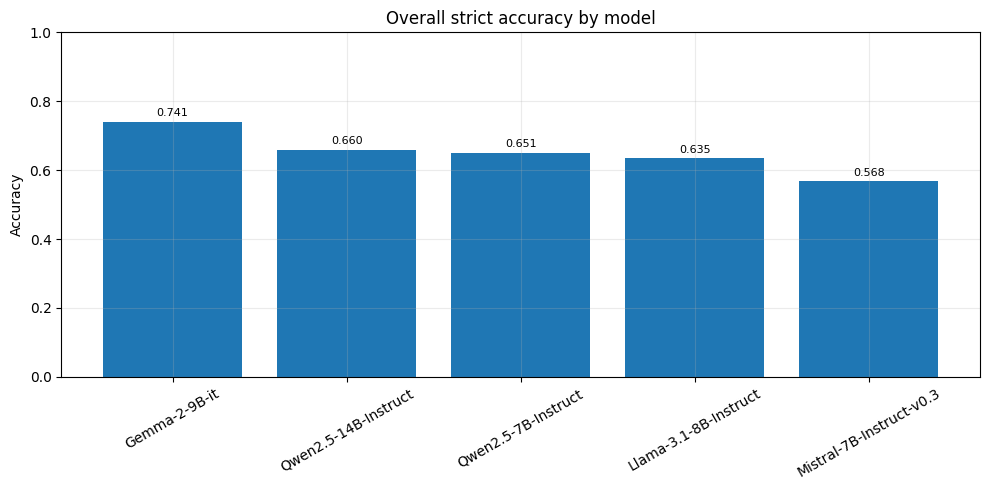

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\overall_parse_failure_by_model.png


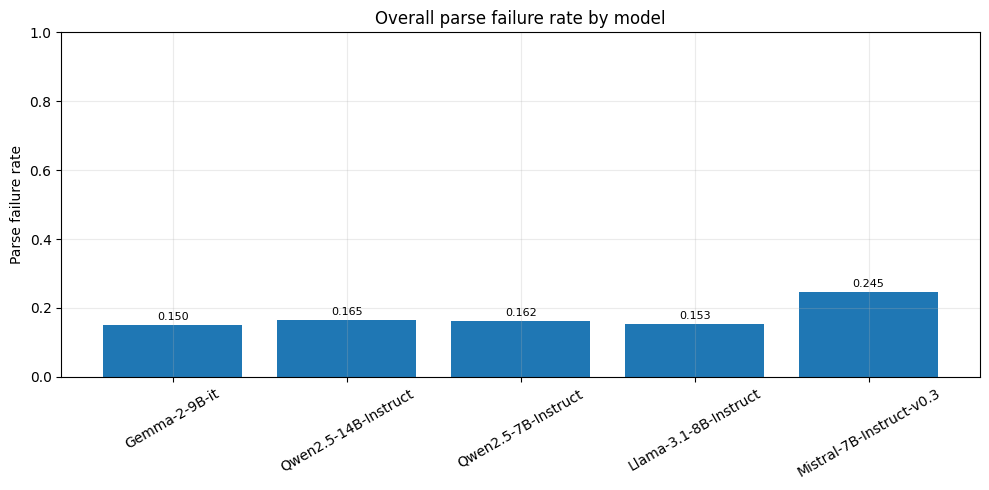

In [52]:
overall = summarize(["model", "model_display", "model_family", "params_b", "is_instruct_model"])
overall = overall.sort_values("accuracy", ascending=False)
save_table(overall, "overall_metrics_notebook.csv")
display(overall)

plot_bar(overall, "model_display", "accuracy", "Overall strict accuracy by model", filename="overall_accuracy_by_model.png")
plot_bar(overall, "model_display", "parse_failure_rate", "Overall parse failure rate by model", ylabel="Parse failure rate", filename="overall_parse_failure_by_model.png")

## 6. Clean vs distracted comparison

This is the main robustness comparison.

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_clean_vs_distracted_long.csv
Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_clean_vs_distracted_drop.csv


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\2717972195.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


condition,model,model_display,clean,distracted,drop_clean_to_distracted
4,mistral_instruct,Mistral-7B-Instruct-v0.3,0.682,0.551714,0.130286
2,qwen7b,Qwen2.5-7B-Instruct,0.740,0.638000,0.102000
0,gemma,Gemma-2-9B-it,0.818,0.730000,0.088000
1,qwen14b,Qwen2.5-14B-Instruct,0.734,0.649143,0.084857
3,llama,Llama-3.1-8B-Instruct,0.682,0.628286,0.053714


Saved plot to: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\clean_vs_distracted_accuracy.png


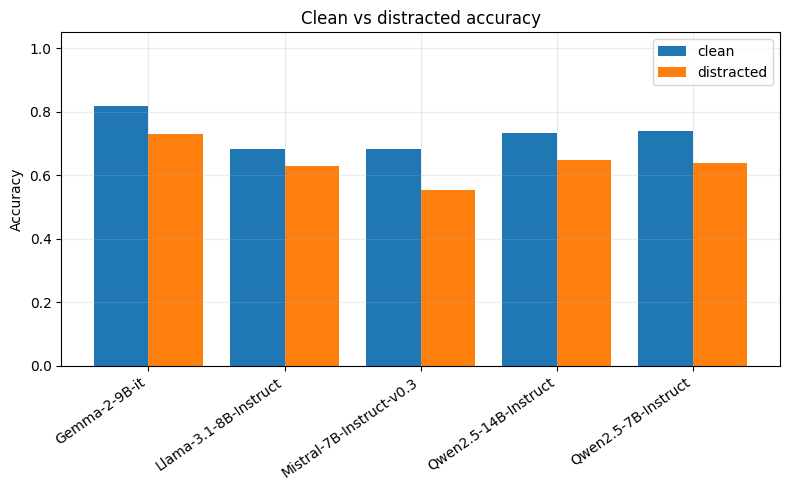

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\clean_to_distracted_drop.png


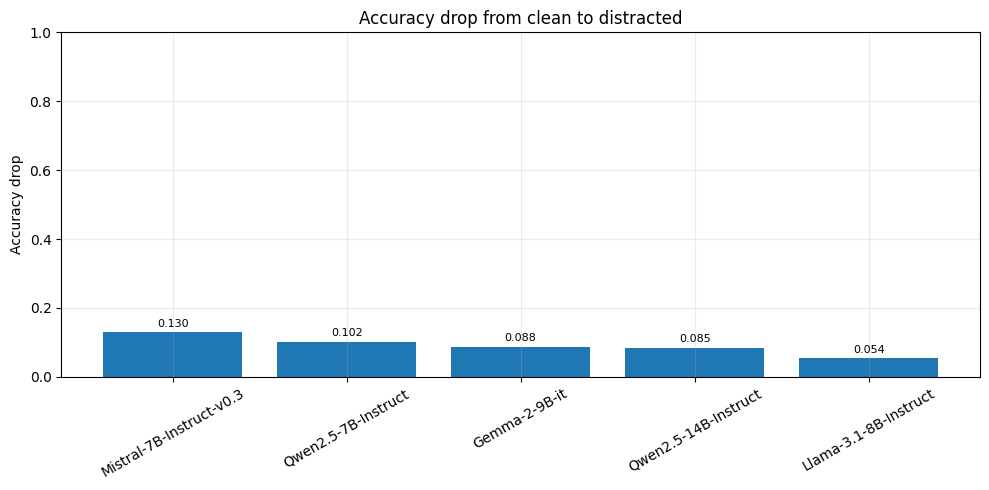

In [53]:
clean_vs = (
    df.groupby(["model", "model_display", "is_clean_bool"], observed=True)
    .agg(
        accuracy=("correct", "mean"),
        parse_failure_rate=("parse_fail", "mean"),
        n=("correct", "count")
    )
    .reset_index()
)

clean_vs["condition"] = np.where(clean_vs["is_clean_bool"], "clean", "distracted")

clean_pivot = (
    clean_vs
    .pivot_table(
        index=["model", "model_display"],
        columns="condition",
        values="accuracy",
        aggfunc="mean"
    )
    .reset_index()
)

clean_pivot["drop_clean_to_distracted"] = clean_pivot["clean"] - clean_pivot["distracted"]
clean_pivot = clean_pivot.sort_values("drop_clean_to_distracted", ascending=False)

save_table(clean_vs, "metrics_clean_vs_distracted_long.csv")
save_table(clean_pivot, "metrics_clean_vs_distracted_drop.csv")

display(clean_pivot)

plot_grouped_bar(
    clean_vs,
    "model_display",
    "condition",
    "accuracy",
    "Clean vs distracted accuracy",
    filename="clean_vs_distracted_accuracy.png"
)

plot_bar(
    clean_pivot,
    "model_display",
    "drop_clean_to_distracted",
    "Accuracy drop from clean to distracted",
    ylabel="Accuracy drop",
    filename="clean_to_distracted_drop.png"
)

## 7. Accuracy and parse failures by task

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_by_task_notebook.csv


,model,model_display,task_name,accuracy,parse_failure_rate,n
0,gemma,Gemma-2-9B-it,single_label_classification,0.91750,0.08250,800
1,gemma,Gemma-2-9B-it,multi_label_classification,0.47625,0.51500,800
2,gemma,Gemma-2-9B-it,information_extraction,0.91500,0.07625,800
3,gemma,Gemma-2-9B-it,rule_based_transformation,0.47250,0.05125,800
4,gemma,Gemma-2-9B-it,extractive_qa,0.92375,0.02750,800
5,qwen14b,Qwen2.5-14B-Instruct,single_label_classification,0.91125,0.08875,800
6,qwen14b,Qwen2.5-14B-Instruct,multi_label_classification,0.38500,0.60750,800
7,qwen14b,Qwen2.5-14B-Instruct,information_extraction,0.91875,0.04625,800
8,qwen14b,Qwen2.5-14B-Instruct,rule_based_transformation,0.39125,0.04375,800
9,qwen14b,Qwen2.5-14B-Instruct,extractive_qa,0.69250,0.04000,800


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\3849492270.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\3849492270.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_accuracy_by_model_task.png


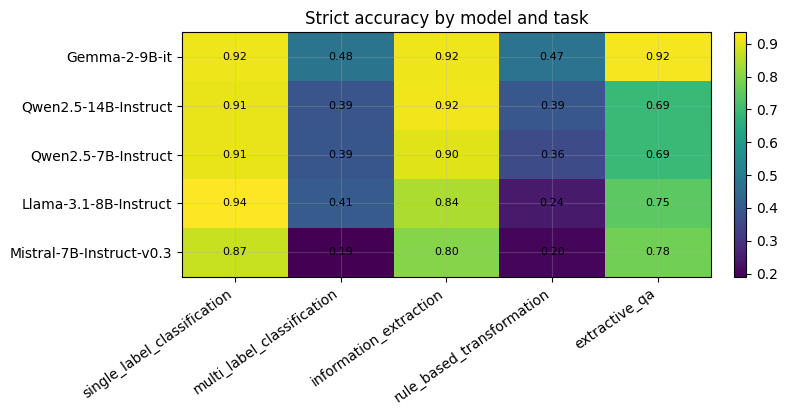

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_parse_failure_by_model_task.png


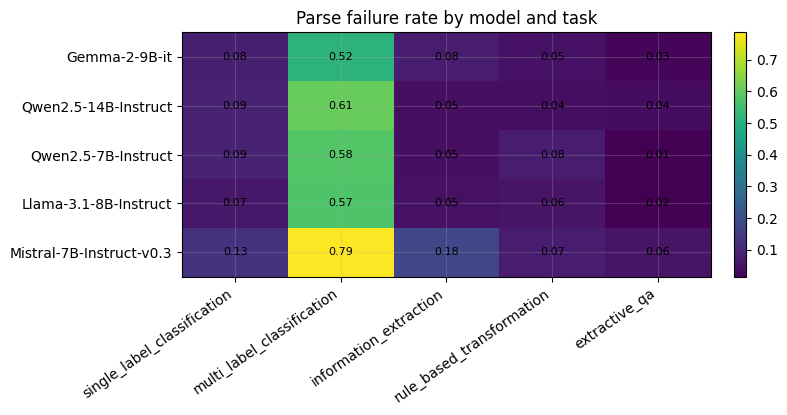

In [54]:
by_task = summarize(["model", "model_display", "task_name"])
save_table(by_task, "metrics_by_task_notebook.csv")
display(by_task.sort_values(["model", "task_name"]))

model_display_order = [
    MODEL_FILES[m]["display"]
    for m in MODEL_ORDER
    if m in df["model"].astype(str).unique()
]

acc_task_pivot = (
    by_task
    .pivot_table(
        index="model_display",
        columns="task_name",
        values="accuracy",
        aggfunc="mean"
    )
    .reindex(model_display_order)
)

parse_task_pivot = (
    by_task
    .pivot_table(
        index="model_display",
        columns="task_name",
        values="parse_failure_rate",
        aggfunc="mean"
    )
    .reindex(model_display_order)
)

plot_heatmap(
    acc_task_pivot,
    "Strict accuracy by model and task",
    filename="heatmap_accuracy_by_model_task.png"
)

plot_heatmap(
    parse_task_pivot,
    "Parse failure rate by model and task",
    filename="heatmap_parse_failure_by_model_task.png"
)

## 8. Bounded vs unbounded regimes

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_by_regime_notebook.csv


,model,model_display,regime,accuracy,parse_failure_rate,n
0,gemma,Gemma-2-9B-it,bounded,0.7595,0.1430,2000
1,gemma,Gemma-2-9B-it,unbounded,0.7225,0.1580,2000
2,qwen14b,Qwen2.5-14B-Instruct,bounded,0.6820,0.1485,2000
3,qwen14b,Qwen2.5-14B-Instruct,unbounded,0.6375,0.1820,2000
4,qwen7b,Qwen2.5-7B-Instruct,bounded,0.6760,0.1495,2000
5,qwen7b,Qwen2.5-7B-Instruct,unbounded,0.6255,0.1745,2000
6,llama,Llama-3.1-8B-Instruct,bounded,0.6305,0.1410,2000
7,llama,Llama-3.1-8B-Instruct,unbounded,0.6395,0.1645,2000
8,mistral_instruct,Mistral-7B-Instruct-v0.3,bounded,0.5800,0.2390,2000
9,mistral_instruct,Mistral-7B-Instruct-v0.3,unbounded,0.5560,0.2510,2000


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\1225360773.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  regime_pivot = by_regime.pivot_table(index="model_display", columns="regime", values="accuracy", aggfunc="mean").reindex(model_display_order)


regime,bounded,unbounded,bounded_minus_unbounded
model_display,,,
Gemma-2-9B-it,0.7595,0.7225,0.0370
Qwen2.5-14B-Instruct,0.6820,0.6375,0.0445
Qwen2.5-7B-Instruct,0.6760,0.6255,0.0505
Llama-3.1-8B-Instruct,0.6305,0.6395,-0.0090
Mistral-7B-Instruct-v0.3,0.5800,0.5560,0.0240


Saved plot to: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\bounded_vs_unbounded_accuracy.png


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\43515440.py:48: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = table.pivot_table(


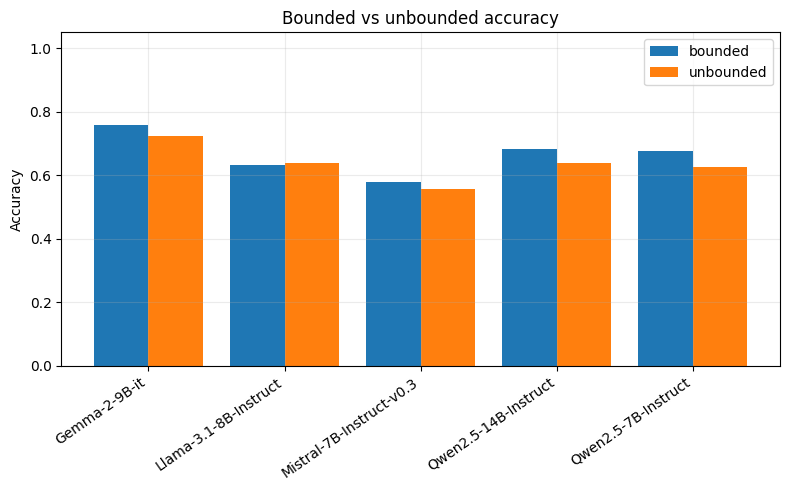

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\bounded_minus_unbounded.png


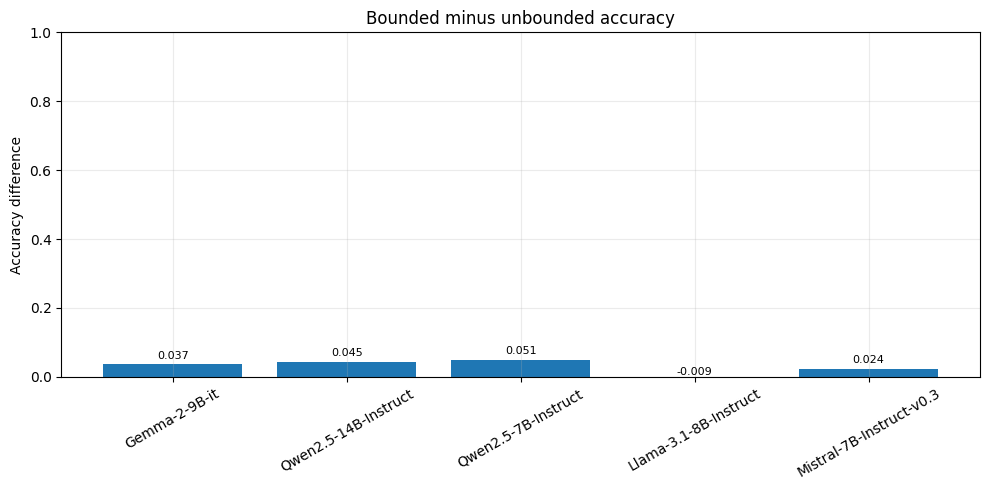

In [55]:
by_regime = summarize(["model", "model_display", "regime"])
save_table(by_regime, "metrics_by_regime_notebook.csv")
display(by_regime)

regime_pivot = by_regime.pivot_table(index="model_display", columns="regime", values="accuracy", aggfunc="mean").reindex(model_display_order)
regime_pivot["bounded_minus_unbounded"] = regime_pivot["bounded"] - regime_pivot["unbounded"]
display(regime_pivot)

plot_grouped_bar(by_regime, "model_display", "regime", "accuracy", "Bounded vs unbounded accuracy", filename="bounded_vs_unbounded_accuracy.png")
plot_bar(regime_pivot.reset_index(), "model_display", "bounded_minus_unbounded", "Bounded minus unbounded accuracy", ylabel="Accuracy difference", filename="bounded_minus_unbounded.png")

# Section B — Distraction robustness

## 9. Accuracy by distraction type

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_by_distraction_type_notebook.csv


,model,model_display,distraction_type,accuracy,parse_failure_rate,n
0,gemma,Gemma-2-9B-it,clean,0.818,0.086,500
1,gemma,Gemma-2-9B-it,irrelevant_prefix,0.792,0.106,500
2,gemma,Gemma-2-9B-it,irrelevant_suffix,0.738,0.132,500
3,gemma,Gemma-2-9B-it,instruction_in_the_middle,0.724,0.142,500
4,gemma,Gemma-2-9B-it,conflicting_instruction,0.518,0.384,500
5,gemma,Gemma-2-9B-it,negation_distraction,0.802,0.088,500
6,gemma,Gemma-2-9B-it,style_distraction,0.748,0.146,500
7,gemma,Gemma-2-9B-it,length_stress,0.788,0.120,500
8,qwen14b,Qwen2.5-14B-Instruct,clean,0.734,0.124,500
9,qwen14b,Qwen2.5-14B-Instruct,irrelevant_prefix,0.698,0.142,500


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\504100204.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  acc_dist_pivot = by_distraction.pivot_table(index="model_display", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(model_display_order)
C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\504100204.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  parse_dist_pivot = by_distraction.pivot_table(index="model_display", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(model_display_order)


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_accuracy_by_model_distraction.png


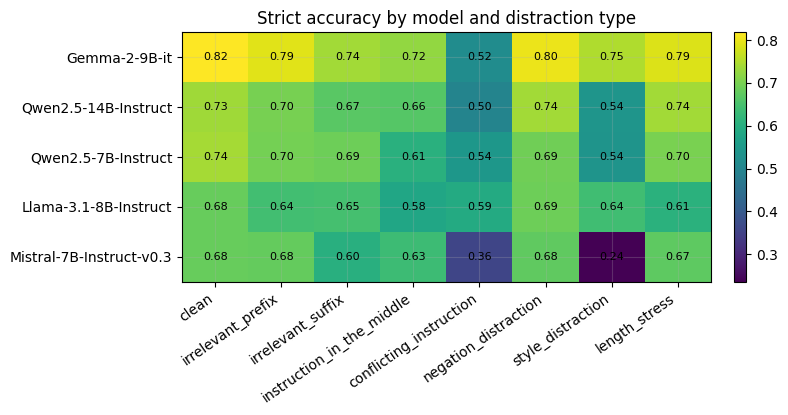

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_parse_failure_by_model_distraction.png


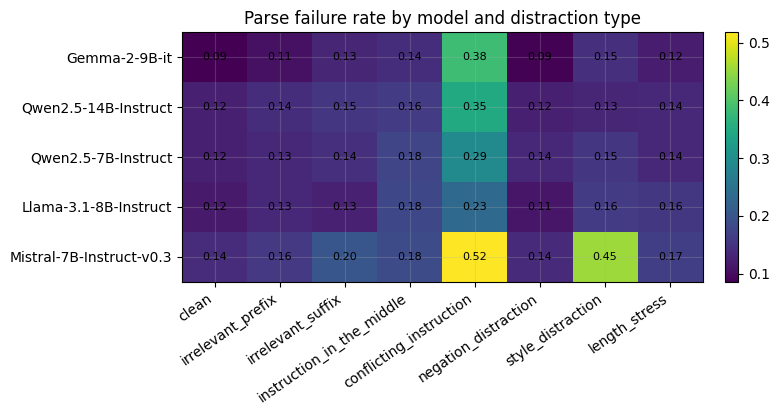

In [56]:
by_distraction = summarize(["model", "model_display", "distraction_type"])
save_table(by_distraction, "metrics_by_distraction_type_notebook.csv")
display(by_distraction.sort_values(["model", "distraction_type"]))

acc_dist_pivot = by_distraction.pivot_table(index="model_display", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(model_display_order)
parse_dist_pivot = by_distraction.pivot_table(index="model_display", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(model_display_order)

plot_heatmap(acc_dist_pivot, "Strict accuracy by model and distraction type", filename="heatmap_accuracy_by_model_distraction.png")
plot_heatmap(parse_dist_pivot, "Parse failure rate by model and distraction type", filename="heatmap_parse_failure_by_model_distraction.png")

## 10. Distraction drop relative to clean

For each model and distraction type:

`drop = clean_accuracy - distraction_accuracy`

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_distraction_drop_vs_clean.csv


,model,model_display,distraction_type,accuracy,parse_failure_rate,n,clean_accuracy,drop_vs_clean
4,gemma,Gemma-2-9B-it,conflicting_instruction,0.518,0.384,500,0.818,0.300
3,gemma,Gemma-2-9B-it,instruction_in_the_middle,0.724,0.142,500,0.818,0.094
2,gemma,Gemma-2-9B-it,irrelevant_suffix,0.738,0.132,500,0.818,0.080
6,gemma,Gemma-2-9B-it,style_distraction,0.748,0.146,500,0.818,0.070
7,gemma,Gemma-2-9B-it,length_stress,0.788,0.120,500,0.818,0.030
1,gemma,Gemma-2-9B-it,irrelevant_prefix,0.792,0.106,500,0.818,0.026
5,gemma,Gemma-2-9B-it,negation_distraction,0.802,0.088,500,0.818,0.016
12,qwen14b,Qwen2.5-14B-Instruct,conflicting_instruction,0.498,0.348,500,0.734,0.236
14,qwen14b,Qwen2.5-14B-Instruct,style_distraction,0.540,0.132,500,0.734,0.194
11,qwen14b,Qwen2.5-14B-Instruct,instruction_in_the_middle,0.664,0.162,500,0.734,0.070


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\94348060.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  drop_pivot = dist_drop.pivot_table(index="model_display", columns="distraction_type", values="drop_vs_clean", aggfunc="mean").reindex(model_display_order)


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_distraction_drop_vs_clean.png


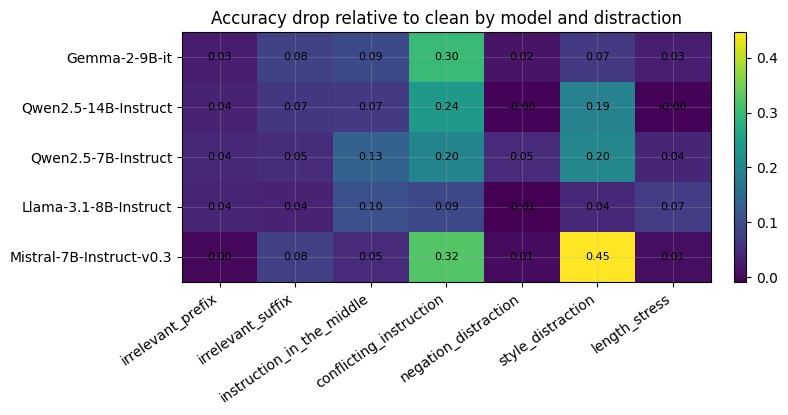

In [57]:
clean_acc = by_distraction[by_distraction["distraction_type"] == "clean"][["model", "accuracy"]].rename(columns={"accuracy": "clean_accuracy"})
dist_drop = by_distraction.merge(clean_acc, on="model", how="left")
dist_drop["drop_vs_clean"] = dist_drop["clean_accuracy"] - dist_drop["accuracy"]
dist_drop = dist_drop[dist_drop["distraction_type"] != "clean"].copy()
save_table(dist_drop, "metrics_distraction_drop_vs_clean.csv")
display(dist_drop.sort_values(["model", "drop_vs_clean"], ascending=[True, False]))

drop_pivot = dist_drop.pivot_table(index="model_display", columns="distraction_type", values="drop_vs_clean", aggfunc="mean").reindex(model_display_order)
plot_heatmap(drop_pivot, "Accuracy drop relative to clean by model and distraction", filename="heatmap_distraction_drop_vs_clean.png")

## 11. Average distraction difficulty across instruct models

This excludes the Mistral base model so that the negative-control baseline does not dominate distraction-family conclusions.

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_distraction_average_instruct_models.csv


,distraction_type,accuracy,parse_failure_rate,n,drop_vs_clean
4,conflicting_instruction,0.5020,0.3552,2500,0.2292
6,style_distraction,0.5404,0.2096,2500,0.1908
3,instruction_in_the_middle,0.6416,0.1688,2500,0.0896
2,irrelevant_suffix,0.6692,0.1516,2500,0.0620
1,irrelevant_prefix,0.7016,0.1348,2500,0.0296
7,length_stress,0.7016,0.1428,2500,0.0296
5,negation_distraction,0.7196,0.1196,2500,0.0116
0,clean,0.7312,0.1184,2500,0.0000


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\avg_instruct_drop_by_distraction.png


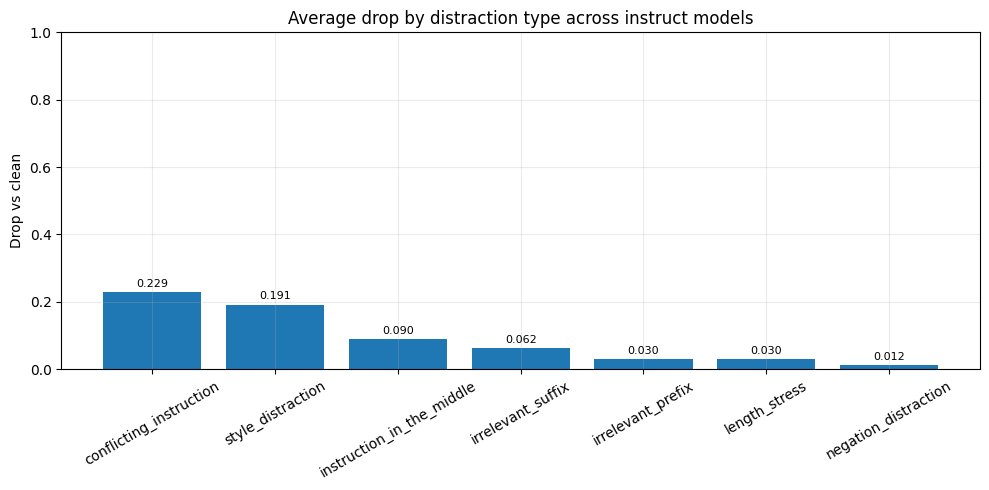

In [58]:
instruct_df = df[df["is_instruct_model"] == True].copy()
by_distraction_instruct = (
    instruct_df.groupby("distraction_type", observed=False)
    .agg(accuracy=("correct", "mean"), parse_failure_rate=("parse_fail", "mean"), n=("correct", "count"))
    .reset_index()
)
clean_instruct_acc = float(by_distraction_instruct.loc[by_distraction_instruct["distraction_type"] == "clean", "accuracy"].iloc[0])
by_distraction_instruct["drop_vs_clean"] = clean_instruct_acc - by_distraction_instruct["accuracy"]
by_distraction_instruct = by_distraction_instruct.sort_values("drop_vs_clean", ascending=False)
save_table(by_distraction_instruct, "metrics_distraction_average_instruct_models.csv")
display(by_distraction_instruct)
plot_bar(by_distraction_instruct[by_distraction_instruct["distraction_type"] != "clean"], "distraction_type", "drop_vs_clean", "Average drop by distraction type across instruct models", ylabel="Drop vs clean", filename="avg_instruct_drop_by_distraction.png")

## 12. Task × distraction interaction

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_task_by_distraction_instruct_models.csv


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\461890281.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  acc_task_dist_pivot = task_dist.pivot_table(index="task_name", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(TASK_ORDER)
C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\461890281.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  parse_task_dist_pivot = task_dist.pivot_table(index="task_name", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(TASK_ORDER)


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_task_distraction_accuracy_instruct.png


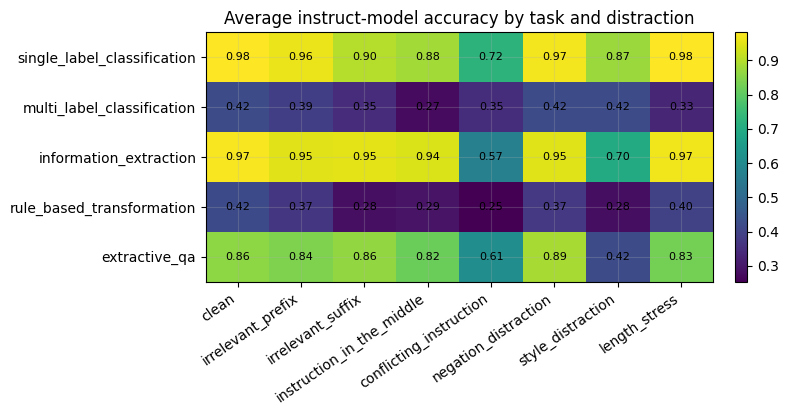

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_task_distraction_parse_failure_instruct.png


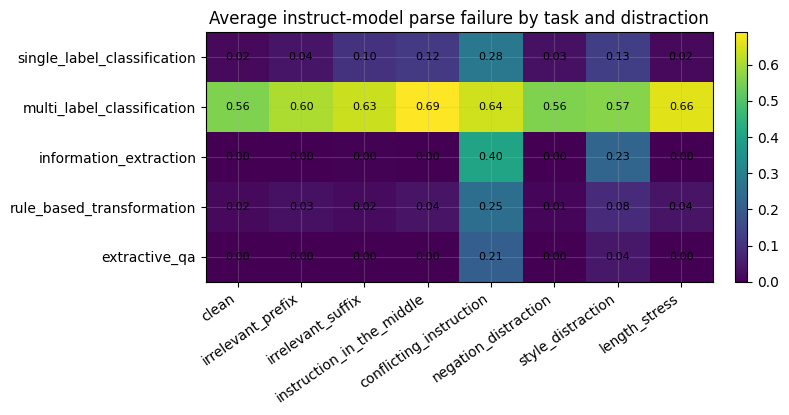

In [59]:
task_dist = (
    instruct_df.groupby(["task_name", "distraction_type"], observed=False)
    .agg(accuracy=("correct", "mean"), parse_failure_rate=("parse_fail", "mean"), n=("correct", "count"))
    .reset_index()
)
save_table(task_dist, "metrics_task_by_distraction_instruct_models.csv")
acc_task_dist_pivot = task_dist.pivot_table(index="task_name", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(TASK_ORDER)
parse_task_dist_pivot = task_dist.pivot_table(index="task_name", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(TASK_ORDER)
plot_heatmap(acc_task_dist_pivot, "Average instruct-model accuracy by task and distraction", filename="heatmap_task_distraction_accuracy_instruct.png")
plot_heatmap(parse_task_dist_pivot, "Average instruct-model parse failure by task and distraction", filename="heatmap_task_distraction_parse_failure_instruct.png")

## 13. Model-specific task × distraction drilldown

Change `SELECTED_MODEL` and rerun this cell to inspect one model in detail.

C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\3827222263.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  one_acc_pivot = one_task_dist.pivot_table(index="task_name", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(TASK_ORDER)
C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\3827222263.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  one_parse_pivot = one_task_dist.pivot_table(index="task_name", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(TASK_ORDER)


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\gemma_task_distraction_accuracy.png


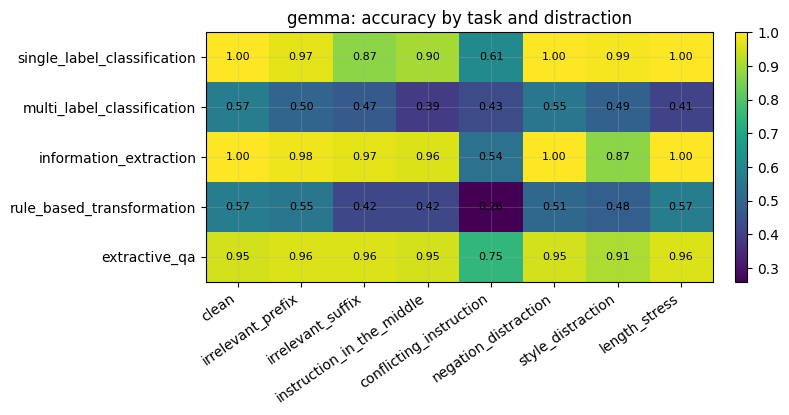

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\gemma_task_distraction_parse_failure.png


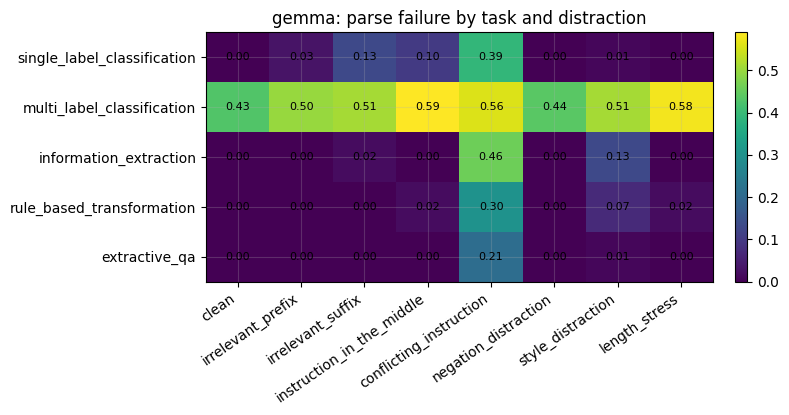

In [60]:
SELECTED_MODEL = "gemma"  # qwen7b, qwen14b, llama, mistral_instruct, gemma

one = df[df["model"].astype(str) == SELECTED_MODEL].copy()
one_task_dist = (
    one.groupby(["task_name", "distraction_type"], observed=False)
    .agg(accuracy=("correct", "mean"), parse_failure_rate=("parse_fail", "mean"), n=("correct", "count"))
    .reset_index()
)
one_acc_pivot = one_task_dist.pivot_table(index="task_name", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(TASK_ORDER)
one_parse_pivot = one_task_dist.pivot_table(index="task_name", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(TASK_ORDER)
plot_heatmap(one_acc_pivot, f"{SELECTED_MODEL}: accuracy by task and distraction", filename=f"{SELECTED_MODEL}_task_distraction_accuracy.png")
plot_heatmap(one_parse_pivot, f"{SELECTED_MODEL}: parse failure by task and distraction", filename=f"{SELECTED_MODEL}_task_distraction_parse_failure.png")

## 14. Regime × distraction interaction

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\metrics_regime_by_distraction_instruct_models.csv


C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\4060962673.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  regime_dist_acc = regime_dist.pivot_table(index="regime", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(REGIME_ORDER)
C:\Users\fmene\AppData\Local\Temp\ipykernel_14864\4060962673.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  regime_dist_parse = regime_dist.pivot_table(index="regime", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(REGIME_ORDER)


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_regime_distraction_accuracy_instruct.png


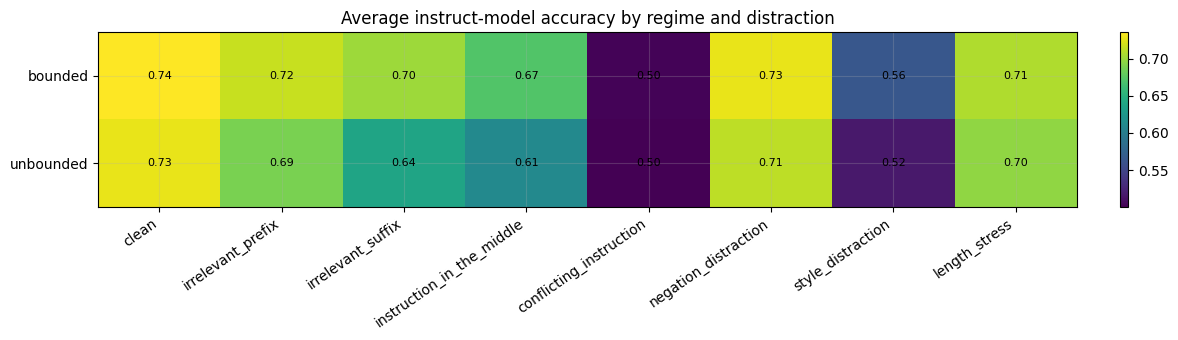

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\heatmap_regime_distraction_parse_failure_instruct.png


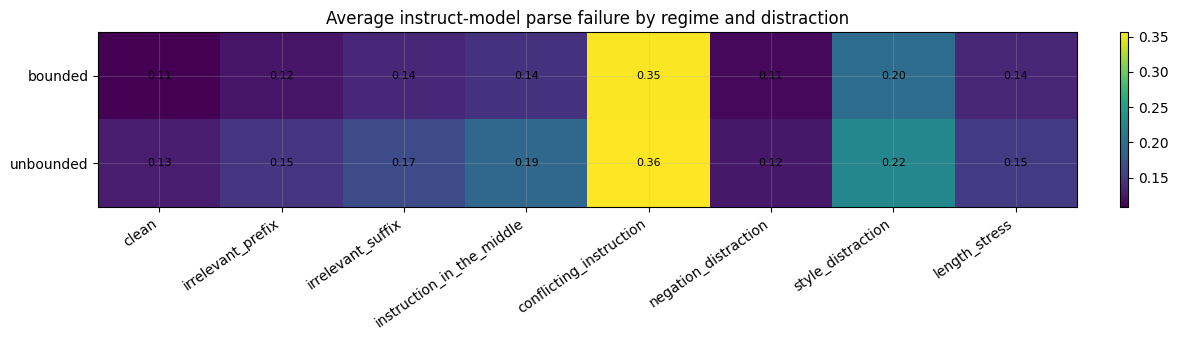

In [61]:
regime_dist = (
    instruct_df.groupby(["regime", "distraction_type"], observed=False)
    .agg(accuracy=("correct", "mean"), parse_failure_rate=("parse_fail", "mean"), n=("correct", "count"))
    .reset_index()
)
save_table(regime_dist, "metrics_regime_by_distraction_instruct_models.csv")
regime_dist_acc = regime_dist.pivot_table(index="regime", columns="distraction_type", values="accuracy", aggfunc="mean").reindex(REGIME_ORDER)
regime_dist_parse = regime_dist.pivot_table(index="regime", columns="distraction_type", values="parse_failure_rate", aggfunc="mean").reindex(REGIME_ORDER)
plot_heatmap(regime_dist_acc, "Average instruct-model accuracy by regime and distraction", filename="heatmap_regime_distraction_accuracy_instruct.png", figsize=(12, 3.5))
plot_heatmap(regime_dist_parse, "Average instruct-model parse failure by regime and distraction", filename="heatmap_regime_distraction_parse_failure_instruct.png", figsize=(12, 3.5))

# Section C — Failure analysis

## 15. Error-code distribution

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\failure_error_codes_by_model.csv


,model,model_display,primary_error_code,count
4,gemma,Gemma-2-9B-it,wrong_answer,434
2,gemma,Gemma-2-9B-it,invalid_label,418
1,gemma,Gemma-2-9B-it,invalid_json,166
3,gemma,Gemma-2-9B-it,missing_key,9
5,gemma,Gemma-2-9B-it,wrong_schema,8
6,gemma,Gemma-2-9B-it,wrong_type,1
0,gemma,Gemma-2-9B-it,extra_key,0
7,gemma,Llama-3.1-8B-Instruct,extra_key,0
8,gemma,Llama-3.1-8B-Instruct,invalid_json,0
9,gemma,Llama-3.1-8B-Instruct,invalid_label,0


,error_code,count
0,wrong_answer,3480
1,invalid_label,2497
2,invalid_json,782
3,missing_key,125
4,wrong_schema,68
5,extra_key,21
6,wrong_type,9


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\top_error_codes_instruct_models.png


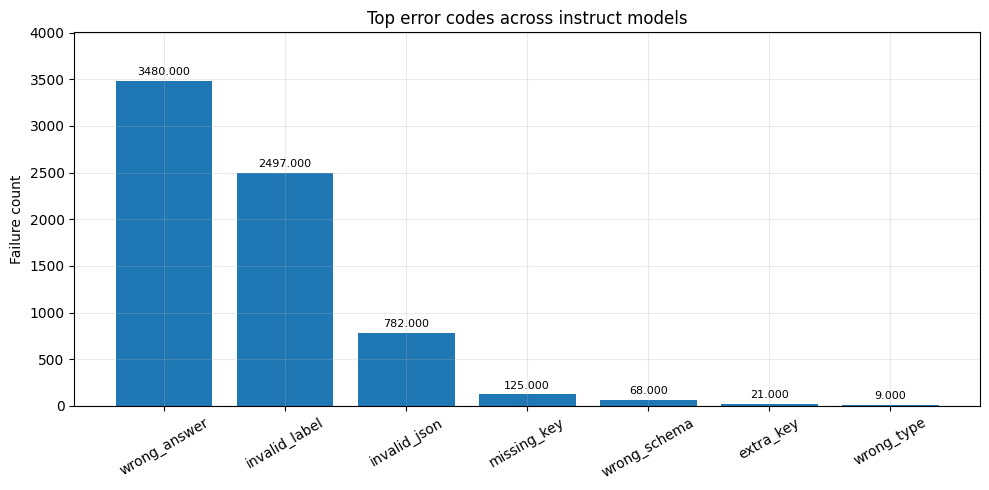

In [62]:
failures = df[df["correct"] == 0].copy()
failures["primary_error_code"] = failures["parse_error_code"].fillna(failures["score_error_code"]).fillna("unknown")

error_by_model = (
    failures.groupby(["model", "model_display", "primary_error_code"], observed=False)
    .size()
    .reset_index(name="count")
    .sort_values(["model", "count"], ascending=[True, False])
)
save_table(error_by_model, "failure_error_codes_by_model.csv")
display(error_by_model.groupby("model", observed=False).head(10))

error_instruct = failures[failures["is_instruct_model"] == True]
error_counts = error_instruct["primary_error_code"].value_counts().reset_index()
error_counts.columns = ["error_code", "count"]
display(error_counts)
plot_bar(error_counts.head(12), "error_code", "count", "Top error codes across instruct models", ylabel="Failure count", filename="top_error_codes_instruct_models.png")

## 16. Load failure-analysis outputs if available

Loaded C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\failure_mode_summary.csv


,model,task_name,distraction_type,suggested_failure_mode,count
0,gemma,multi_label_classification,instruction_in_the_middle,invalid_label,59
1,gemma,multi_label_classification,length_stress,invalid_label,58
2,gemma,rule_based_transformation,irrelevant_suffix,transformation_mismatch,58
3,gemma,rule_based_transformation,instruction_in_the_middle,transformation_mismatch,56
4,gemma,multi_label_classification,irrelevant_suffix,invalid_label,51
5,gemma,multi_label_classification,irrelevant_prefix,invalid_label,50
6,gemma,rule_based_transformation,negation_distraction,transformation_mismatch,49
7,gemma,multi_label_classification,style_distraction,invalid_label,47
8,gemma,rule_based_transformation,irrelevant_prefix,transformation_mismatch,45
9,gemma,rule_based_transformation,style_distraction,transformation_mismatch,45


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\failure_mode_summary_loaded.csv


,suggested_failure_mode,count
4,invalid_label,2497
7,transformation_mismatch,2422
3,invalid_json_or_extra_text,782
6,span_inflation,741
5,schema_violation,223
2,entity_or_field_mismatch,182
8,wrong_label_set,69
9,wrong_span,30
1,empty_answer,29
0,case_or_surface_mismatch,7


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\top_suggested_failure_modes.png


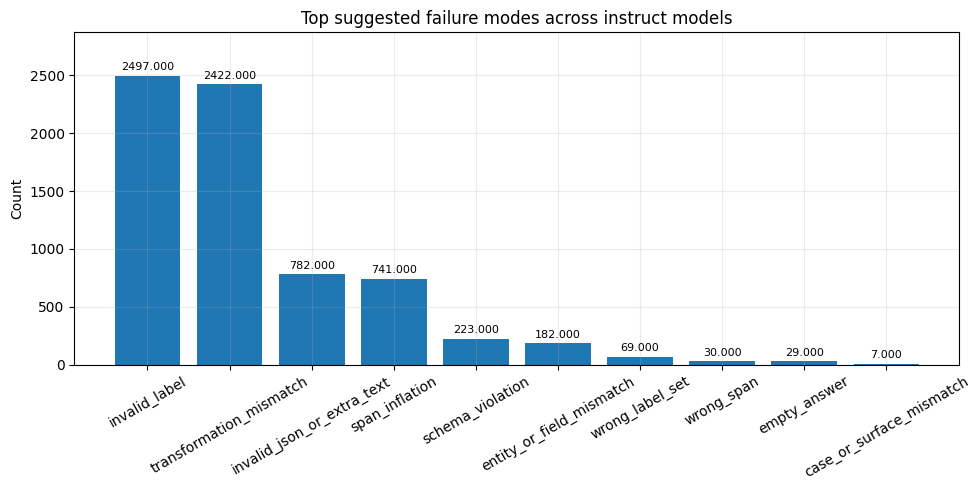

Loaded C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\failure_samples.csv (549, 18)


,model,prompt_id,base_example_id,task_name,regime,distraction_type,distraction_subtype,prompt_surface_type,parse_success,parse_error_code,score_error_code,suggested_failure_mode,gold_short,pred_short,raw_output_short,prompt_text_short,manual_failure_label,manual_notes
0,gemma,qa_248__bounded__clean,qa_248,extractive_qa,bounded,clean,NaN,bounded_tagged,True,NaN,wrong_answer,span_inflation,fitness watch,a fitness watch,"{""answer"": ""a fitness watch""}","Review the request below, then use the provided material.\n\n<TASK>\nCopy the answer directly from the passage.\n</TASK>\n\n<INPUT>\nPassage:\nEarlier drafts mentioned a protot...",NaN,NaN
1,gemma,qa_249__unbounded__clean,qa_249,extractive_qa,unbounded,clean,NaN,message_like,True,NaN,wrong_answer,span_inflation,security platform,a security platform,"{""answer"": ""a security platform""}",I need this processed.\n\nExtract the answer directly from the passage without paraphrasing.\n\nHere is the material:\nPassage:\nEarlier drafts mentioned a prototype from Nova ...,NaN,NaN
2,gemma,qa_248__unbounded__clean,qa_248,extractive_qa,unbounded,clean,NaN,message_like,True,NaN,wrong_answer,span_inflation,fitness watch,a fitness watch,"{""answer"": ""a fitness watch""}","Can you help with a quick text task?\n\nCopy the answer directly from the passage.\n\nPassage:\nEarlier drafts mentioned a prototype from GreenBridge Analytics, but the final r...",NaN,NaN
3,gemma,qa_220__unbounded__conflicting_instruction,qa_220,extractive_qa,unbounded,conflicting_instruction,late_override_note,benchmark_like,False,invalid_json,invalid_json,invalid_json_or_extra_text,Madrid,NaN,DONE,"Validation item\n\nInstruction:\nUse the passage wording exactly for the answer.\n\nInput:\nPassage:\nAlice Smith first suggested meeting in Seville, but the final note states ...",NaN,NaN
4,gemma,qa_237__unbounded__conflicting_instruction,qa_237,extractive_qa,unbounded,conflicting_instruction,conflicting_task_substitution,message_like,False,missing_key,missing_key,schema_violation,Alice Smith,NaN,"{""topic"": ""Meeting Schedule Change""}",I need this processed.\n\nExtract the answer directly from the passage without paraphrasing.\n\nHere is the material:\nPassage:\nAlice Smith said the meeting in Prague would st...,NaN,NaN
5,gemma,qa_203__unbounded__conflicting_instruction,qa_203,extractive_qa,unbounded,conflicting_instruction,conflicting_format_override,memo_like,False,invalid_json,invalid_json,invalid_json_or_extra_text,BlueRiver Health,NaN,"* {""answer"": ""BlueRiver Health""}",Please complete the item below.\n\nRequested operation: Extract the answer directly from the passage without paraphrasing.\n\nContent to use:\nPassage:\nThe deployment note say...,NaN,NaN
6,gemma,qa_248__bounded__instruction_in_the_middle,qa_248,extractive_qa,bounded,instruction_in_the_middle,middle_burial,bounded_tagged,True,NaN,wrong_answer,span_inflation,fitness watch,a fitness watch,"{""answer"": ""a fitness watch""}","Meeting notes mention parking access, delivery timings, and a delayed update to the building access list. A follow-up discussion on signage changes was moved to next Tuesday.\n...",NaN,NaN
7,gemma,qa_249__unbounded__instruction_in_the_middle,qa_249,extractive_qa,unbounded,instruction_in_the_middle,middle_burial,message_like,True,NaN,wrong_answer,span_inflation,security platform,the security platform,"{""answer"": ""the security platform""}","The team reviewed onboarding documents, account resets, and unresolved questions about archive permissions. No final timeline was set for the migration checklist.\n\nI need thi...",NaN,NaN
8,gemma,qa_248__unbounded__instruction_in_the_middle,qa_248,extractive_qa,unbounded,instruction_in_the_middle,middle_burial,message_like,True,NaN,wrong_answer,span_inflation,fitness watch,a fitness watch,"{""answer"": ""a fitness watch""}","Meeting notes mention parking access, delivery timings, and a delayed update to the building access list. A follow-up discussion on signage changes was moved to next Tue

In [63]:
candidate_failure_summary_paths = [
    FAILURE_OUTPUT_DIR / "failure_mode_summary.csv",
    PROJECT_ROOT / "analysis_outputs" / "failure_mode_summary.csv",
    PROJECT_ROOT / "failure_mode_summary.csv",
]
failure_summary_path = next((p for p in candidate_failure_summary_paths if p.exists()), None)

if failure_summary_path:
    failure_mode_summary = pd.read_csv(failure_summary_path)
    failure_mode_summary = failure_mode_summary[
        ~failure_mode_summary["model"].astype(str).isin(EXCLUDED_MODEL_KEYS)
    ].copy()
    print("Loaded", failure_summary_path)
    display(failure_mode_summary.head(20))
    save_table(failure_mode_summary, "failure_mode_summary_loaded.csv")

    fms_instruct = failure_mode_summary[failure_mode_summary["model"] != "mistral_base"].copy()
    global_failure_modes = fms_instruct.groupby("suggested_failure_mode")["count"].sum().reset_index().sort_values("count", ascending=False)
    display(global_failure_modes)
    plot_bar(global_failure_modes.head(15), "suggested_failure_mode", "count", "Top suggested failure modes across instruct models", ylabel="Count", filename="top_suggested_failure_modes.png")
else:
    print("No failure_mode_summary.csv found. Expected first at:", FAILURE_OUTPUT_DIR / "failure_mode_summary.csv")

candidate_failure_sample_paths = [
    FAILURE_OUTPUT_DIR / "failure_samples.csv",
    PROJECT_ROOT / "analysis_outputs" / "failure_samples.csv",
    PROJECT_ROOT / "failure_samples.csv",
]
failure_samples_path = next((p for p in candidate_failure_sample_paths if p.exists()), None)

if failure_samples_path:
    failure_samples = pd.read_csv(failure_samples_path)
    failure_samples = failure_samples[
        ~failure_samples["model"].astype(str).isin(EXCLUDED_MODEL_KEYS)
    ].copy()
    print("Loaded", failure_samples_path, failure_samples.shape)
    display(failure_samples.head(20))
else:
    print("No failure_samples.csv found. Expected first at:", FAILURE_OUTPUT_DIR / "failure_samples.csv")


# Section D — Relaxed QA sensitivity analysis

Strict exact match remains the primary metric. This secondary analysis asks how many extractive-QA failures are minor article/case/punctuation near-misses.

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\relaxed_overall_metrics.csv


,model,model_display,strict_accuracy,relaxed_accuracy,relaxed_gain,n
0,gemma,Gemma-2-9B-it,0.74100,0.75075,0.00975,4000
8,qwen14b,Qwen2.5-14B-Instruct,0.65975,0.69350,0.03375,4000
14,qwen7b,Qwen2.5-7B-Instruct,0.65075,0.67800,0.02725,4000
16,llama,Llama-3.1-8B-Instruct,0.63500,0.66875,0.03375,4000
22,mistral_instruct,Mistral-7B-Instruct-v0.3,0.56800,0.57000,0.00200,4000
1,gemma,Llama-3.1-8B-Instruct,NaN,NaN,NaN,0
2,gemma,Mistral-7B-Instruct-v0.3,NaN,NaN,NaN,0
3,gemma,Qwen2.5-14B-Instruct,NaN,NaN,NaN,0
4,gemma,Qwen2.5-7B-Instruct,NaN,NaN,NaN,0
5,qwen14b,Gemma-2-9B-it,NaN,NaN,NaN,0


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\qa_relaxed_by_model.csv


,model,model_display,strict_qa_accuracy,relaxed_qa_accuracy,recovered_rate_within_qa,n
0,gemma,Gemma-2-9B-it,0.92375,0.97250,0.04875,800
16,llama,Llama-3.1-8B-Instruct,0.74750,0.91625,0.16875,800
8,qwen14b,Qwen2.5-14B-Instruct,0.69250,0.86125,0.16875,800
14,qwen7b,Qwen2.5-7B-Instruct,0.69500,0.83125,0.13625,800
22,mistral_instruct,Mistral-7B-Instruct-v0.3,0.77625,0.78625,0.01000,800
1,gemma,Llama-3.1-8B-Instruct,NaN,NaN,NaN,0
2,gemma,Mistral-7B-Instruct-v0.3,NaN,NaN,NaN,0
3,gemma,Qwen2.5-14B-Instruct,NaN,NaN,NaN,0
4,gemma,Qwen2.5-7B-Instruct,NaN,NaN,NaN,0
5,qwen14b,Gemma-2-9B-it,NaN,NaN,NaN,0


Saved plot to: C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\plots\strict_vs_relaxed_qa_accuracy.png


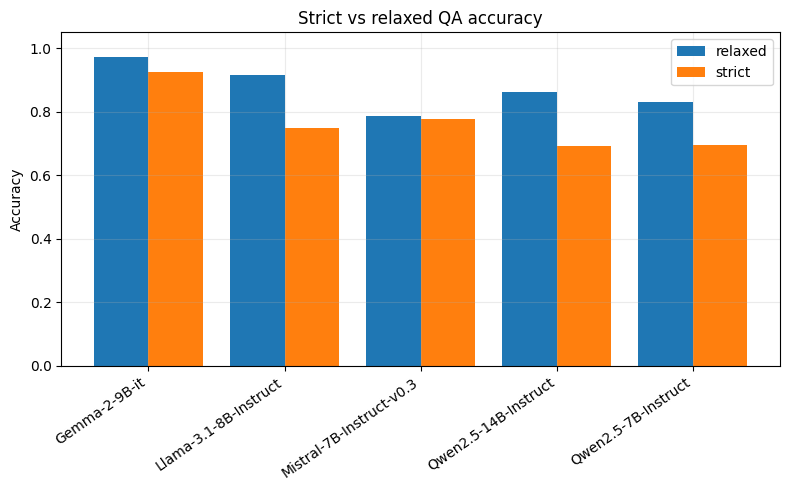

In [64]:
ARTICLES_RE = re.compile(r"^(a|an|the)\s+", flags=re.IGNORECASE)

def normalize_qa_answer(s):
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = ARTICLES_RE.sub("", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    s = " ".join(s.split())
    return s


def extract_answer_from_obj(obj, key):
    if isinstance(obj, dict):
        return obj.get(key)
    return None


def qa_relaxed_match(row):
    if row.get("task_name") != "extractive_qa":
        return bool(row.get("is_correct"))
    if not bool(row.get("parse_success")):
        return False
    gold = extract_answer_from_obj(row.get("gold_output"), "answer")
    pred = extract_answer_from_obj(row.get("parsed_output"), "answer")
    return normalize_qa_answer(gold) == normalize_qa_answer(pred)

relaxed_df = df.copy()
relaxed_df["relaxed_correct"] = relaxed_df.apply(qa_relaxed_match, axis=1).astype(int)
relaxed_df["strict_correct"] = relaxed_df["correct"]
relaxed_df["relaxed_recovered"] = ((relaxed_df["strict_correct"] == 0) & (relaxed_df["relaxed_correct"] == 1)).astype(int)

relaxed_overall = (
    relaxed_df.groupby(["model", "model_display"], observed=False)
    .agg(
        strict_accuracy=("strict_correct", "mean"),
        relaxed_accuracy=("relaxed_correct", "mean"),
        relaxed_gain=("relaxed_recovered", "mean"),
        n=("strict_correct", "count"),
    )
    .reset_index()
    .sort_values("relaxed_accuracy", ascending=False)
)
save_table(relaxed_overall, "relaxed_overall_metrics.csv")
display(relaxed_overall)

qa_relaxed_by_model = (
    relaxed_df[relaxed_df["task_name"] == "extractive_qa"]
    .groupby(["model", "model_display"], observed=False)
    .agg(
        strict_qa_accuracy=("strict_correct", "mean"),
        relaxed_qa_accuracy=("relaxed_correct", "mean"),
        recovered_rate_within_qa=("relaxed_recovered", "mean"),
        n=("strict_correct", "count"),
    )
    .reset_index()
    .sort_values("relaxed_qa_accuracy", ascending=False)
)
save_table(qa_relaxed_by_model, "qa_relaxed_by_model.csv")
display(qa_relaxed_by_model)

qa_melt = qa_relaxed_by_model.rename(columns={"strict_qa_accuracy": "strict", "relaxed_qa_accuracy": "relaxed"}).melt(
    id_vars=["model", "model_display"], value_vars=["strict", "relaxed"], var_name="metric", value_name="accuracy"
)
plot_grouped_bar(qa_melt, "model_display", "metric", "accuracy", "Strict vs relaxed QA accuracy", filename="strict_vs_relaxed_qa_accuracy.png")

## 17. QA failure categories after relaxed matching

In [65]:
def classify_qa_failure(row):
    if row.get("task_name") != "extractive_qa":
        return None
    if bool(row.get("is_correct")):
        return "strict_correct"
    if bool(row.get("relaxed_correct")):
        return "article_case_punctuation_near_miss"
    if not bool(row.get("parse_success")):
        return row.get("parse_error_code") or "parse_failure"
    gold = extract_answer_from_obj(row.get("gold_output"), "answer")
    pred = extract_answer_from_obj(row.get("parsed_output"), "answer")
    if pred in [None, ""]:
        return "empty_answer"
    if isinstance(gold, str) and isinstance(pred, str):
        if gold in pred and gold != pred:
            return "span_inflation_contains_gold"
        if normalize_qa_answer(gold) in normalize_qa_answer(pred) and normalize_qa_answer(gold) != normalize_qa_answer(pred):
            return "normalized_span_inflation_contains_gold"
    return "wrong_span"

qa_df = relaxed_df[relaxed_df["task_name"] == "extractive_qa"].copy()
qa_df["qa_failure_category"] = qa_df.apply(classify_qa_failure, axis=1)

qa_breakdown = (
    qa_df.groupby(["model", "model_display", "qa_failure_category"], observed=False)
    .size()
    .reset_index(name="count")
    .sort_values(["model", "count"], ascending=[True, False])
)
save_table(qa_breakdown, "qa_failure_breakdown_after_relaxed_matching.csv")
display(qa_breakdown)

qa_recovered = qa_df[qa_df["relaxed_recovered"] == 1].copy()
qa_recovered["gold_answer"] = qa_recovered["gold_output"].apply(lambda x: x.get("answer") if isinstance(x, dict) else None)
qa_recovered["pred_answer"] = qa_recovered["parsed_output"].apply(lambda x: x.get("answer") if isinstance(x, dict) else None)
qa_recovered_cols = ["model", "prompt_id", "regime", "distraction_type", "gold_answer", "pred_answer", "raw_output"]
save_table(qa_recovered[qa_recovered_cols].head(300), "qa_relaxed_recovered_examples.csv")
display(qa_recovered[qa_recovered_cols].head(20))

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\qa_failure_breakdown_after_relaxed_matching.csv


,model,model_display,qa_failure_category,count
7,gemma,Gemma-2-9B-it,strict_correct,739
0,gemma,Gemma-2-9B-it,article_case_punctuation_near_miss,39
3,gemma,Gemma-2-9B-it,invalid_json,20
4,gemma,Gemma-2-9B-it,missing_key,2
1,gemma,Gemma-2-9B-it,empty_answer,0
...,...,...,...,...
270,mistral_instruct,Qwen2.5-7B-Instruct,span_inflation_contains_gold,0
271,mistral_instruct,Qwen2.5-7B-Instruct,strict_correct,0
272,mistral_instruct,Qwen2.5-7B-Instruct,wrong_schema,0
273,mistral_instruct,Qwen2.5-7B-Instruct,wrong_span,0


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\qa_relaxed_recovered_examples.csv


,model,prompt_id,regime,distraction_type,gold_answer,pred_answer,raw_output
660,gemma,qa_241__bounded__conflicting_instruction,bounded,conflicting_instruction,security platform,a security platform,"{""answer"": ""a security platform""}"
669,gemma,qa_241__unbounded__negation_distraction,unbounded,negation_distraction,security platform,a security platform,"{""answer"": ""a security platform""}"
670,gemma,qa_241__unbounded__style_distraction,unbounded,style_distraction,security platform,a security platform,"{""answer"": ""a security platform""}"
704,gemma,qa_244__bounded__clean,bounded,clean,budget phone,a budget phone,"{""answer"": ""a budget phone""}"
707,gemma,qa_244__bounded__instruction_in_the_middle,bounded,instruction_in_the_middle,budget phone,a budget phone,"{""answer"": ""a budget phone""}"
710,gemma,qa_244__bounded__style_distraction,bounded,style_distraction,budget phone,a budget phone,"{""answer"": ""a budget phone""}"
718,gemma,qa_244__unbounded__style_distraction,unbounded,style_distraction,budget phone,a budget phone,"{""answer"": ""a budget phone""}"
758,gemma,qa_247__bounded__style_distraction,bounded,style_distraction,solar battery,a solar battery,"{""answer"": ""a solar battery""}"
768,gemma,qa_248__bounded__clean,bounded,clean,fitness watch,a fitness watch,"{""answer"": ""a fitness watch""}"
769,gemma,qa_248__bounded__irrelevant_prefix,bounded,irrelevant_prefix,fitness watch,a fitness watch,"{""answer"": ""a fitness watch""}"


# Section E — Thesis-ready summary tables

In [66]:
leaderboard = overall[["model", "model_display", "accuracy", "parse_failure_rate", "n"]].merge(
    clean_pivot[["model", "clean", "distracted", "drop_clean_to_distracted"]],
    on="model",
    how="left",
)
leaderboard = leaderboard.sort_values("accuracy", ascending=False)
save_table(leaderboard, "thesis_model_leaderboard.csv")
display(leaderboard)

worst_distraction = (
    dist_drop.sort_values(["model", "drop_vs_clean"], ascending=[True, False])
    .groupby("model", observed=False)
    .head(1)
    [["model", "model_display", "distraction_type", "accuracy", "drop_vs_clean", "parse_failure_rate"]]
    .reset_index(drop=True)
)
save_table(worst_distraction, "thesis_worst_distraction_per_model.csv")
display(worst_distraction)

by_task_ranked = by_task.sort_values(["model", "accuracy"], ascending=[True, True])
hardest_task = by_task_ranked.groupby("model", observed=False).head(1)[["model", "model_display", "task_name", "accuracy", "parse_failure_rate"]]
save_table(hardest_task, "thesis_hardest_task_per_model.csv")
display(hardest_task)

Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\thesis_model_leaderboard.csv


,model,model_display,accuracy,parse_failure_rate,n,clean,distracted,drop_clean_to_distracted
0,gemma,Gemma-2-9B-it,0.74100,0.15050,4000,0.818,0.730000,0.088000
1,qwen14b,Qwen2.5-14B-Instruct,0.65975,0.16525,4000,0.734,0.649143,0.084857
2,qwen7b,Qwen2.5-7B-Instruct,0.65075,0.16200,4000,0.740,0.638000,0.102000
3,llama,Llama-3.1-8B-Instruct,0.63500,0.15275,4000,0.682,0.628286,0.053714
4,mistral_instruct,Mistral-7B-Instruct-v0.3,0.56800,0.24500,4000,0.682,0.551714,0.130286


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\thesis_worst_distraction_per_model.csv


,model,model_display,distraction_type,accuracy,drop_vs_clean,parse_failure_rate
0,gemma,Gemma-2-9B-it,conflicting_instruction,0.518,0.300,0.384
1,qwen14b,Qwen2.5-14B-Instruct,conflicting_instruction,0.498,0.236,0.348
2,qwen7b,Qwen2.5-7B-Instruct,style_distraction,0.538,0.202,0.154
3,llama,Llama-3.1-8B-Instruct,instruction_in_the_middle,0.580,0.102,0.180
4,mistral_instruct,Mistral-7B-Instruct-v0.3,style_distraction,0.236,0.446,0.454


Saved C:\code\testing\LLMs_Robustness_Under_Distractions\evaluation\analysis_outputs\notebook_exports\tables\thesis_hardest_task_per_model.csv


,model,model_display,task_name,accuracy,parse_failure_rate
3,gemma,Gemma-2-9B-it,rule_based_transformation,0.4725,0.05125
6,qwen14b,Qwen2.5-14B-Instruct,multi_label_classification,0.3850,0.60750
13,qwen7b,Qwen2.5-7B-Instruct,rule_based_transformation,0.3600,0.07750
18,llama,Llama-3.1-8B-Instruct,rule_based_transformation,0.2425,0.05625
21,mistral_instruct,Mistral-7B-Instruct-v0.3,multi_label_classification,0.1900,0.78625


In [67]:
best = leaderboard.iloc[0]
worst_useful = leaderboard.sort_values("accuracy").iloc[0]
avg_drop = leaderboard["drop_clean_to_distracted"].mean()
worst_global_distraction = by_distraction_instruct[by_distraction_instruct["distraction_type"] != "clean"].sort_values("accuracy").iloc[0]

summary_lines = [
    "Automatic summary draft:",
    "",
    f"- Best overall model: {best['model_display']} with strict accuracy {best['accuracy']:.3f}.",
    f"- Weakest instruct model overall: {worst_useful['model_display']} with strict accuracy {worst_useful['accuracy']:.3f}.",
    f"- Average clean-to-distracted drop among instruct models: {avg_drop:.3f}.",
    f"- Most harmful distraction on average among instruct models: {worst_global_distraction['distraction_type']} with accuracy {worst_global_distraction['accuracy']:.3f}.",
    "- Mistral base was excluded from the main analysis because it failed almost entirely at the parsing/interface level.",
]
summary_text = "".join(summary_lines)
print(summary_text)
(OUTPUT_DIR / "automatic_summary_draft.txt").write_text(summary_text, encoding="utf-8")

Automatic summary draft:- Best overall model: Gemma-2-9B-it with strict accuracy 0.741.- Weakest instruct model overall: Mistral-7B-Instruct-v0.3 with strict accuracy 0.568.- Average clean-to-distracted drop among instruct models: 0.092.- Most harmful distraction on average among instruct models: conflicting_instruction with accuracy 0.502.- Mistral base was excluded from the main analysis because it failed almost entirely at the parsing/interface level.


458

# Final notes

Recommended thesis structure from this notebook:

1. **Overall model comparison** — leaderboard and parse-failure rates.
2. **Robustness drop** — clean vs distracted accuracy.
3. **Distraction-family effects** — conflicting instructions, style distractions, length stress, etc.
4. **Task-family effects** — multi-label and transformation are the hardest.
5. **Regime comparison** — bounded vs unbounded.
6. **Failure analysis** — invalid labels, transformation mismatches, span-boundary near-misses, schema violations.
7. **Relaxed QA sensitivity analysis** — strict scores are primary, but QA near-misses are separately quantified.

All generated CSVs and plots are saved under:

`evaluation/analysis_outputs/notebook_exports/`